In [1]:
!pip install huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.7/536.7 kB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 120.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [huggingface_hub] [huggingface_hub]


In [2]:
import os
import yaml
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm
from huggingface_hub import hf_hub_download

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [3]:
BENCH_DIR = "/home/dnanexus/data_dir/other_benchmarks"
# BENCH_DIR = "/s/project/deeprvat/ukb_gym/other_benchmarks"

# UKBBGym

In [5]:
!mkdir -p {BENCH_DIR}
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"

# ANNO_FILE = "annotations_fillna_ukbgym.parquet"
ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {BENCH_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{BENCH_DIR}/{ANNO_FILE}")

mac = 20

consequence_columns = [c for c in anno.collect_schema().names() if c.startswith("consequence_")]

anno = (
    anno
    .select(['id', 'region'] + consequence_columns)
    .unpivot(
        index=['id', 'region'],
        on=consequence_columns,
        variable_name='variant_region',
        value_name='value'
    )
    .filter(pl.col('value') == 1)
    .drop('value')
    .collect(engine='streaming')
)
anno

Error: path "/home/dnanexus/data_dir/other_benchmarks/annotations_fillna_ukbgy
m_with_mane.parquet" already exists but -f/--overwrite was not set


id,region,variant_region
str,str,str
"""chr15:50559082:C:G""","""ENSG00000092439""","""consequence_3_prime_utr_varian…"
"""chr7:148415711:C:CTTAAAATATCAG…","""ENSG00000174469""","""consequence_3_prime_utr_varian…"
"""chr1:243501559:C:T""","""ENSG00000117020""","""consequence_3_prime_utr_varian…"
"""chr1:92510691:G:T""","""ENSG00000067208""","""consequence_3_prime_utr_varian…"
"""chr11:119417400:A:G""","""ENSG00000154096""","""consequence_3_prime_utr_varian…"
…,…,…
"""chr19:41258834:A:G""","""ENSG00000105323""","""consequence_upstream_gene_vari…"
"""chr15:69412613:G:A""","""ENSG00000137807""","""consequence_upstream_gene_vari…"
"""chr10:111073068:T:G""","""ENSG00000150594""","""consequence_upstream_gene_vari…"


In [ ]:
['non_mane_exons', 'non_mane_exonic']
non_mane_vars = (
    anno
    .select(['id', 'region'] + consequence_columns)
    .unpivot(
        index=['id', 'region'],
        on=consequence_columns,
        variable_name='variant_region',
        value_name='value'
    )
    .filter(pl.col('value') == 1)
    .drop('value')
    .collect(engine='streaming')
)
non_mane_vars

## UKBBGmm phenos

In [5]:
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var/loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet -o /home/dnanexus/data_dir/loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet

appv = pl.scan_parquet("/home/dnanexus/data_dir/loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value_ptile', 'n_individuals']
    )
)

Error: path "/home/dnanexus/data_dir/loftee_mac20_quant_pheno_assocs_EURunrela
ted_appv_percentiles.parquet" already exists but -f/--overwrite was not set


In [6]:
# Get gene trait associations
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/regenie_127phenotypes_lofteeHC_mac20_EUR.parquet -o /home/dnanexus/data_dir/
# !dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/loftee_mac20_associations_bh_corrected.parquet -o /home/dnanexus/data_dir/

!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet -o /home/dnanexus/data_dir/

gene_trait_df = (
    pl.read_parquet('/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR.parquet')
    .filter(pl.col('pval_fdr')<=0.05)
    .select(['region', 'phenotype', 'pval_fdr'])
)

loftee_corrs = (
    pl.read_parquet('/home/dnanexus/data_dir/regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

gene_trait_df = (
    gene_trait_df
    .join(loftee_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    .sort('loftee_corr_abs', descending=True)
    .unique(subset=["region"], keep="first", maintain_order=True)
)
gene_trait_df

Error: path
"/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR.parquet"
already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_mac20_lofteeHC_EUR_
correlations.parquet" already exists but -f/--overwrite was not set


region,phenotype,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64,f64
"""ENSG00000244734""","""mean_corpuscular_haemoglobin_i…",5.8426e-107,-0.414609,0.414609,-1.0
"""ENSG00000188536""","""mean_corpuscular_haemoglobin_i…",4.2593e-22,-0.366514,0.366514,-1.0
"""ENSG00000101439""","""cystatin_c_int""",9.0570e-172,-0.364046,0.364046,-1.0
"""ENSG00000167941""","""heel_bone_mineral_density_bmd_…",0.004143,0.309961,0.309961,1.0
"""ENSG00000149948""","""standing_height_int""",0.035047,-0.302164,0.302164,-1.0
…,…,…,…,…,…
"""ENSG00000162992""","""glycated_haemoglobin_hba1c_int""",0.000525,0.004895,0.004895,1.0
"""ENSG00000134030""","""leg_fat_percentage_right_int""",0.028495,0.003606,0.003606,1.0
"""ENSG00000114796""","""position_of_pulse_wave_notch_i…",0.03963,-0.003476,0.003476,-1.0


In [7]:
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())

ukbgym_pheno = (
    appv
    .join(
        anno_ids_lazy, 
        on="id", 
        how="semi"
    )
    .join(
        anno.lazy(), 
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )
    .with_columns(
        mean_pheno_value_dircor_ptile = pl.when(pl.col('loftee_corr_dir') == -1)
            .then(1 - pl.col('mean_pheno_value_ptile'))
            .otherwise(pl.col('mean_pheno_value_ptile')),
    )
    .with_columns(
        pathogenic = (pl.col('mean_pheno_value_dircor_ptile') > 0.9995).cast(pl.Int8),
        
        benchmark = pl.lit("UKBBGym phenotypes"),
    )
    .collect(engine='streaming')
)

ukbgym_pheno

id,phenotype,mean_pheno_value_ptile,n_individuals,region,variant_region,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir,mean_pheno_value_dircor_ptile,pathogenic,benchmark
str,str,f32,i32,str,str,f64,f64,f64,f64,f32,i8,str
"""chr19:7288358:C:G""","""apolipoprotein_b_int""",0.044021,1,"""ENSG00000171105""","""consequence_intron_variant""",0.007933,-0.065906,0.065906,-1.0,0.955979,0,"""UKBBGym phenotypes"""
"""chr19:7127078:CAT:C""","""apolipoprotein_b_int""",0.140596,1,"""ENSG00000171105""","""consequence_intron_variant""",0.007933,-0.065906,0.065906,-1.0,0.859404,0,"""UKBBGym phenotypes"""
"""chr19:7126159:G:C""","""apolipoprotein_b_int""",0.063943,3,"""ENSG00000171105""","""consequence_intron_variant""",0.007933,-0.065906,0.065906,-1.0,0.936057,0,"""UKBBGym phenotypes"""
"""chr19:7246219:T:C""","""apolipoprotein_b_int""",0.159095,6,"""ENSG00000171105""","""consequence_intron_variant""",0.007933,-0.065906,0.065906,-1.0,0.840905,0,"""UKBBGym phenotypes"""
"""chr19:7244780:T:G""","""apolipoprotein_b_int""",0.072451,1,"""ENSG00000171105""","""consequence_intron_variant""",0.007933,-0.065906,0.065906,-1.0,0.927549,0,"""UKBBGym phenotypes"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr11:72240464:G:T""","""whole_body_water_mass_int""",0.001136,4,"""ENSG00000165458""","""consequence_downstream_gene_va…",0.030338,0.127209,0.127209,1.0,0.001136,0,"""UKBBGym phenotypes"""
"""chr11:72240515:T:C""","""whole_body_water_mass_int""",0.004671,1,"""ENSG00000165458""","""consequence_downstream_gene_va…",0.030338,0.127209,0.127209,1.0,0.004671,0,"""UKBBGym phenotypes"""
"""chr11:72239916:C:A""","""whole_body_water_mass_int""",0.00418,1,"""ENSG00000165458""","""consequence_downstream_gene_va…",0.030338,0.127209,0.127209,1.0,0.00418,0,"""UKBBGym phenotypes"""


# Other Benchmarks

## ClinVar

In [8]:
# Download ClinVar VCF (GRCh38) and its index
!mkdir -p {BENCH_DIR}/clinvar
!wget -nc https://ftp.ncbi.nlm.nih.gov/pub/clinvar/vcf_GRCh38/clinvar.vcf.gz -O {BENCH_DIR}/clinvar/clinvar.vcf.gz
!wget -nc https://ftp.ncbi.nlm.nih.gov/pub/clinvar/vcf_GRCh38/clinvar.vcf.gz.tbi -O {BENCH_DIR}/clinvar/clinvar.vcf.gz.tbi

File ‘/home/dnanexus/data_dir/other_benchmarks/clinvar/clinvar.vcf.gz’ already there; not retrieving.
File ‘/home/dnanexus/data_dir/other_benchmarks/clinvar/clinvar.vcf.gz.tbi’ already there; not retrieving.


In [9]:
# 1. Create a dummy dataframe with your example string (added CLNSIG for demonstration)
data = {
    "info_col": [
        ".11:g.917887G>T;CLNVC=single_nucleotide_variant;CLNVCSO=SO:0001483;GENEINFO=LINC02593:100130417;MC=SO:0001627|intron_variant;ORIGIN=0",
        "CLNVC=single_nucleotide_variant;CLNSIG=Likely_benign;MC=SO:0001583|missense_variant;ORIGIN=1",
        "CLNVC=deletion;CLNSIG=Pathogenic;MC=SO:0001587|stop_gained;ORIGIN=1"
    ]
}
df = pl.DataFrame(data)

# 2. Extract the fields using Regex
# We create two new columns by parsing the 'info_col'
df.with_columns(
    # Regex explanation for MC: 
    # Look for "MC=", skip characters until pipe "|", capture text until next comma or semicolon
    variant_region = pl.col("info_col").str.extract(r"MC=[^|]+\|([^;,]+)", 1),
    
    # Regex explanation for CLNSIG: 
    # Look for "CLNSIG=", capture everything until the next semicolon
    clinical_significance = pl.col("info_col").str.extract(r"CLNSIG=([^;]+)", 1)
)

info_col,variant_region,clinical_significance
str,str,str
""".11:g.917887G>T;CLNVC=single_n…","""intron_variant""",null
"""CLNVC=single_nucleotide_varian…","""missense_variant""","""Likely_benign"""
"""CLNVC=deletion;CLNSIG=Pathogen…","""stop_gained""","""Pathogenic"""


In [10]:
clinvar = (
    pl.read_csv(f"{BENCH_DIR}/clinvar/clinvar.vcf.gz", comment_prefix="##", separator="\t", ignore_errors=True)
    .with_columns(
        chrom = pl.col("#CHROM").fill_null("NA"),
    
        # Look for "CLNSIG=", capture everything until the next semicolon
        clinical_significance = pl.col("INFO").str.extract(r"CLNSIG=([^;]+)", 1),
    )
    .with_columns(
        id = pl.col("chrom").cast(str) + ":" + pl.col("POS").cast(str) + ":" + pl.col("REF") + ":" + pl.col("ALT"),

        # Look for "MC=", skip characters until pipe "|", capture text until next comma or semicolon
        variant_region = pl.col("INFO").str.extract(r"MC=[^|]+\|([^;,]+)", 1),

        pathogenic = (
            pl.when(pl.col("clinical_significance").is_in(["Pathogenic", "Likely_pathogenic"])).then(1).otherwise(0)
            # pl.when(pl.col("clinical_significance").is_in(["Pathogenic", "Likely_pathogenic"])).then(1)
            # .otherwise(pl.when(pl.col("clinical_significance").is_in(["Benign", "Likely_benign"])).then(0).otherwise(None))
        ).cast(pl.Int8),

        benchmark = pl.lit("ClinVar"),
    )
)

clinvar

#CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,chrom,clinical_significance,id,variant_region,pathogenic,benchmark
i64,i64,i64,str,str,str,str,str,str,str,str,str,i8,str
1,66926,3385321,"""AG""","""A""",""".""",""".""","""ALLELEID=3544463;CLNDISDB=Huma…","""1""","""Uncertain_significance""","""1:66926:AG:A""","""intron_variant""",0,"""ClinVar"""
1,69134,2205837,"""A""","""G""",""".""",""".""","""ALLELEID=2193183;CLNDISDB=MedG…","""1""","""Likely_benign""","""1:69134:A:G""","""missense_variant""",0,"""ClinVar"""
1,69241,4562067,"""C""","""T""",""".""",""".""","""ALLELEID=4679177;CLNDISDB=MedG…","""1""","""Uncertain_significance""","""1:69241:C:T""","""missense_variant""",0,"""ClinVar"""
1,69308,3925305,"""A""","""G""",""".""",""".""","""ALLELEID=4039319;CLNDISDB=MedG…","""1""","""Uncertain_significance""","""1:69308:A:G""","""missense_variant""",0,"""ClinVar"""
1,69314,3205580,"""T""","""G""",""".""",""".""","""ALLELEID=3374047;CLNDISDB=MedG…","""1""","""Uncertain_significance""","""1:69314:T:G""","""missense_variant""",0,"""ClinVar"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…
null,274185,3778023,"""C""","""T""",""".""",""".""","""ALLELEID=3894028;CLNDISDB=MedG…","""NA""","""Likely_benign""","""NA:274185:C:T""","""intron_variant""",0,"""ClinVar"""
null,274366,2206666,"""G""","""C""",""".""",""".""","""ALLELEID=2200058;CLNDISDB=MedG…","""NA""","""Uncertain_significance""","""NA:274366:G:C""","""missense_variant""",0,"""ClinVar"""
null,275068,2241971,"""T""","""C""",""".""",""".""","""ALLELEID=2226217;CLNDISDB=MedG…","""NA""","""Uncertain_significance""","""NA:275068:T:C""","""missense_variant""",0,"""ClinVar"""


## TraitGym

In [11]:
# Download the file to your local cache and get the path
file_path = hf_hub_download(
    repo_id="songlab/TraitGym", 
    filename="mendelian_traits_matched_9/test.parquet",
    repo_type="dataset"
)

# 1. Define the mapping dictionary
ccre_to_vep = {
    # Promoters
    "PLS": "promoter_variant",
    "PLS_flank": "promoter_variant",
    
    # Enhancers (Proximal and Distal)
    "pELS": "enhancer_variant",
    "pELS_flank": "regulatory_region_variant",
    "dELS": "enhancer_variant",
    "dELS_flank": "regulatory_region_variant", # Generic regulatory term for flanking regions
    
    # Transcription Factors
    "CTCF-only": "TF_binding_site_variant",
    "CTCF-only_flank": "regulatory_region_variant",
    
    # Ambiguous / Poised regions
    "DNase-H3K4me3": "regulatory_region_variant",
    "DNase-H3K4me3_flank": "regulatory_region_variant" 
}


# Read the local file
trait_gym_m = (
    pl.read_parquet(file_path)
    .with_columns(
        id = pl.concat_str([
            pl.col("chrom").cast(pl.Utf8),
            pl.lit(":"),
            pl.col("pos").cast(pl.Utf8),
            pl.lit(":"),
            pl.col("ref"),
            pl.lit(":"),
            pl.col("alt")
        ]),
        variant_region = (
            pl.when(pl.col("consequence").is_in(ccre_to_vep.keys()))
            .then(pl.col("consequence").replace(ccre_to_vep, default=None))
            .otherwise(pl.col("consequence"))
        ),
        pathogenic = pl.col('label').cast(pl.Int8),
        benchmark = pl.lit("TraitGym mendelian traits (matched)")
    )
)
trait_gym_m

/tmp/ipykernel_391269/239123848.py:45: DeprecationWarning: the `default` parameter for `replace` is deprecated. Use `replace_strict` instead to set a default while replacing values.
(Deprecated in version 1.0.0)


chrom,pos,ref,alt,OMIM,consequence,label,tss_dist,match_group,id,variant_region,pathogenic,benchmark
str,i64,str,str,str,str,bool,i64,str,str,str,i8,str
"""1""",1425822,"""C""","""G""",null,"""PLS""",false,48,"""PLS_4""","""1:1425822:C:G""","""promoter_variant""",0,"""TraitGym mendelian traits (mat…"
"""1""",1615869,"""C""","""T""",null,"""PLS""",false,35,"""PLS_0""","""1:1615869:C:T""","""promoter_variant""",0,"""TraitGym mendelian traits (mat…"
"""1""",1659060,"""G""","""A""",null,"""PLS""",false,47,"""PLS_4""","""1:1659060:G:A""","""promoter_variant""",0,"""TraitGym mendelian traits (mat…"
"""1""",1659114,"""A""","""G""",null,"""PLS""",false,101,"""PLS_5""","""1:1659114:A:G""","""promoter_variant""",0,"""TraitGym mendelian traits (mat…"
"""1""",2050958,"""T""","""C""",null,"""5_prime_UTR_variant""",false,149,"""5_prime_UTR_variant_7""","""1:2050958:T:C""","""5_prime_UTR_variant""",0,"""TraitGym mendelian traits (mat…"
…,…,…,…,…,…,…,…,…,…,…,…,…
"""X""",155613005,"""C""","""T""",null,"""PLS""",false,52,"""PLS_52""","""X:155613005:C:T""","""promoter_variant""",0,"""TraitGym mendelian traits (mat…"
"""X""",155719093,"""C""","""A""",null,"""5_prime_UTR_variant""",false,4,"""5_prime_UTR_variant_101""","""X:155719093:C:A""","""5_prime_UTR_variant""",0,"""TraitGym mendelian traits (mat…"
"""X""",155881342,"""A""","""C""",null,"""PLS""",false,2,"""PLS_57""","""X:155881342:A:C""","""promoter_variant""",0,"""TraitGym mendelian traits (mat…"


In [12]:
trait_gym_m['variant_region'].unique()

variant_region
str
"""3_prime_UTR_variant"""
"""non_coding_transcript_exon_var…"
"""promoter_variant"""
"""intergenic_variant"""
"""5_prime_UTR_variant"""
"""upstream_gene_variant"""
"""enhancer_variant"""
"""intron_variant"""
"""regulatory_region_variant"""


In [13]:
# Download the file to your local cache and get the path
file_path = hf_hub_download(
    repo_id="songlab/TraitGym", 
    filename="complex_traits_matched_9/test.parquet",
    repo_type="dataset"
)

# Read the local file
trait_gym_c = (
    pl.read_parquet(file_path)
    .with_columns(
        id = pl.concat_str([
            pl.col("chrom").cast(pl.Utf8),
            pl.lit(":"),
            pl.col("pos").cast(pl.Utf8),
            pl.lit(":"),
            pl.col("ref"),
            pl.lit(":"),
            pl.col("alt")
        ]),
        variant_region = (
            pl.when(pl.col("consequence").is_in(ccre_to_vep.keys()))
            .then(pl.col("consequence").replace(ccre_to_vep, default=None))
            .otherwise(pl.col("consequence"))
        ),
        pathogenic = pl.col('label').cast(pl.Int8),
        benchmark = pl.lit("TraitGym mendelian traits (matched)")
    )
)
trait_gym_c

/tmp/ipykernel_391269/793439815.py:23: DeprecationWarning: the `default` parameter for `replace` is deprecated. Use `replace_strict` instead to set a default while replacing values.
(Deprecated in version 1.0.0)


chrom,pos,ref,alt,pip,trait,label,maf,ld_score,consequence,tss_dist,match_group,id,variant_region,pathogenic,benchmark
str,i64,str,str,f64,str,bool,f64,f64,str,i64,str,str,str,i8,str
"""1""",867476,"""C""","""T""",0.00156,"""""",false,0.079465,44.053,"""non_coding_transcript_exon_var…",56446,"""non_coding_transcript_exon_var…","""1:867476:C:T""","""non_coding_transcript_exon_var…",0,"""TraitGym mendelian traits (mat…"
"""1""",868052,"""T""","""C""",0.001791,"""""",false,0.077747,44.057,"""non_coding_transcript_exon_var…",55870,"""non_coding_transcript_exon_var…","""1:868052:T:C""","""non_coding_transcript_exon_var…",0,"""TraitGym mendelian traits (mat…"
"""1""",868635,"""A""","""G""",0.004349,"""""",false,0.075255,43.639,"""non_coding_transcript_exon_var…",55287,"""non_coding_transcript_exon_var…","""1:868635:A:G""","""non_coding_transcript_exon_var…",0,"""TraitGym mendelian traits (mat…"
"""1""",870176,"""T""","""A""",0.0,"""""",false,0.084371,37.271,"""non_coding_transcript_exon_var…",53746,"""non_coding_transcript_exon_var…","""1:870176:T:A""","""non_coding_transcript_exon_var…",0,"""TraitGym mendelian traits (mat…"
"""1""",1052930,"""A""","""G""",0.001467,"""""",false,0.058385,46.907,"""non_coding_transcript_exon_var…",18823,"""non_coding_transcript_exon_var…","""1:1052930:A:G""","""non_coding_transcript_exon_var…",0,"""TraitGym mendelian traits (mat…"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""22""",50368376,"""T""","""C""",0.0,"""""",false,0.19181,86.507,"""dELS""",3695,"""dELS_204""","""22:50368376:T:C""","""enhancer_variant""",0,"""TraitGym mendelian traits (mat…"
"""22""",50571623,"""C""","""T""",0.0,"""""",false,0.061159,23.9,"""dELS""",6291,"""dELS_202""","""22:50571623:C:T""","""enhancer_variant""",0,"""TraitGym mendelian traits (mat…"
"""22""",50671289,"""G""","""A""",0.0,"""""",false,0.036223,12.733,"""pELS_flank""",3125,"""pELS_flank_26""","""22:50671289:G:A""","""regulatory_region_variant""",0,"""TraitGym mendelian traits (mat…"


## ProteinGym

In [14]:
VERSION = "v1.3"
FILENAME = "DMS_ProteinGym_substitutions.zip"
TARGET_DIR = f"{BENCH_DIR}/protein_gym"
TARGET_FILE = f"{TARGET_DIR}/{FILENAME}"

# 1. Create Directory
!mkdir -p {TARGET_DIR}

# 2. Download only if missing
if not os.path.exists(TARGET_FILE):
    print("File not found. Downloading...")
    !curl -o {TARGET_FILE} https://marks.hms.harvard.edu/proteingym/ProteinGym_{VERSION}/{FILENAME}
else:
    print("File already exists. Skipping download.")

# 3. Unzip with "Yes to All" (-o)
# We use -o to overwrite if it exists, avoiding the interactive prompt
print("Unzipping...")
!unzip -o {TARGET_FILE} -d {TARGET_DIR}

File already exists. Skipping download.
Unzipping...
Archive:  /home/dnanexus/data_dir/other_benchmarks/protein_gym/DMS_ProteinGym_substitutions.zip
  inflating: /home/dnanexus/data_dir/other_benchmarks/protein_gym/DMS_ProteinGym_substitutions/SDA_BACSU_Tsuboyama_2023_1PV0.csv  
  inflating: /home/dnanexus/data_dir/other_benchmarks/protein_gym/DMS_ProteinGym_substitutions/PAI1_HUMAN_Huttinger_2021.csv  
  inflating: /home/dnanexus/data_dir/other_benchmarks/protein_gym/DMS_ProteinGym_substitutions/S22A1_HUMAN_Yee_2023_activity.csv  
  inflating: /home/dnanexus/data_dir/other_benchmarks/protein_gym/DMS_ProteinGym_substitutions/HIS7_YEAST_Pokusaeva_2019.csv  
  inflating: /home/dnanexus/data_dir/other_benchmarks/protein_gym/DMS_ProteinGym_substitutions/AMIE_PSEAE_Wrenbeck_2017.csv  
  inflating: /home/dnanexus/data_dir/other_benchmarks/protein_gym/DMS_ProteinGym_substitutions/ACE2_HUMAN_Chan_2020.csv  
  inflating: /home/dnanexus/data_dir/other_benchmarks/protein_gym/DMS_ProteinGym_substi

In [15]:
VERSION = "v1.3"
FILENAME = "DMS_ProteinGym_indels.zip"
TARGET_DIR = f"{BENCH_DIR}/protein_gym"
TARGET_FILE = f"{TARGET_DIR}/{FILENAME}"

# 1. Create Directory
!mkdir -p {TARGET_DIR}

# 2. Download only if missing
if not os.path.exists(TARGET_FILE):
    print("File not found. Downloading...")
    !curl -o {TARGET_FILE} https://marks.hms.harvard.edu/proteingym/ProteinGym_{VERSION}/{FILENAME}
else:
    print("File already exists. Skipping download.")

# 3. Unzip with "Yes to All" (-o)
# We use -o to overwrite if it exists, avoiding the interactive prompt
print("Unzipping...")
!unzip -o {TARGET_FILE} -d {TARGET_DIR}

File already exists. Skipping download.
Unzipping...
Archive:  /home/dnanexus/data_dir/other_benchmarks/protein_gym/DMS_ProteinGym_indels.zip
  inflating: /home/dnanexus/data_dir/other_benchmarks/protein_gym/DMS_ProteinGym_indels/SDA_BACSU_Tsuboyama_2023_1PV0_indels.csv  
  inflating: /home/dnanexus/data_dir/other_benchmarks/protein_gym/DMS_ProteinGym_indels/PR40A_HUMAN_Tsuboyama_2023_1UZC_indels.csv  
  inflating: /home/dnanexus/data_dir/other_benchmarks/protein_gym/DMS_ProteinGym_indels/BBC1_YEAST_Tsuboyama_2023_1TG0_indels.csv  
  inflating: /home/dnanexus/data_dir/other_benchmarks/protein_gym/DMS_ProteinGym_indels/MBD11_ARATH_Tsuboyama_2023_6ACV_indels.csv  
  inflating: /home/dnanexus/data_dir/other_benchmarks/protein_gym/DMS_ProteinGym_indels/YNZC_BACSU_Tsuboyama_2023_2JVD_indels.csv  
  inflating: /home/dnanexus/data_dir/other_benchmarks/protein_gym/DMS_ProteinGym_indels/HCP_LAMBD_Tsuboyama_2023_2L6Q_indels.csv  
  inflating: /home/dnanexus/data_dir/other_benchmarks/protein_gym/

In [16]:
# csv_pattern = f"{TARGET_DIR}/**/*HUMAN*.csv"
csv_pattern = f"{TARGET_DIR}/DMS_ProteinGym_substitutions/*HUMAN*.csv"

print(f"Scanning files matching: {csv_pattern}")

# 2. Scan and Compile
# 'include_file_paths' creates a column with the file path, which is 
# critical to distinguish which assay the variants come from.
proteingym_snp = (
    pl.scan_csv(csv_pattern, include_file_paths="source_file")
    .with_columns(
        # Extract just the assay name (remove path and extension)
        assay_id = pl.col("source_file")
                    .str.split("/")
                    .list.last()
                    .str.strip_suffix(".csv")
    )
    .collect()

    .with_columns(
        # 1. Flag Bottom 1%
        is_bottom_1pct = pl.col("DMS_score") <= pl.col("DMS_score").quantile(0.01).over("assay_id"),
        
        # 2. Flag Top 1%
        is_top_1pct = pl.col("DMS_score") >= pl.col("DMS_score").quantile(0.99).over("assay_id")
    )
    .with_columns(
        id = pl.col('mutant'),
        variant_region = pl.lit("missense_variant"),
        pathogenic = (pl.col("is_bottom_1pct") | pl.col("is_top_1pct")).cast(pl.Int8),
        benchmark = pl.lit("ProteinGym SNP (Human)"),
    )
)

proteingym_snp

Scanning files matching: /home/dnanexus/data_dir/other_benchmarks/protein_gym/DMS_ProteinGym_substitutions/*HUMAN*.csv


mutant,mutated_sequence,DMS_score,DMS_score_bin,source_file,assay_id,is_bottom_1pct,is_top_1pct,id,variant_region,pathogenic,benchmark
str,str,f64,i64,str,str,bool,bool,str,str,i8,str
"""A673C""","""MLPGLALLLLAAWTARALEVPTDGNAGLLA…",-1.018869,1,"""/home/dnanexus/data_dir/other_…","""A4_HUMAN_Seuma_2022""",false,false,"""A673C""","""missense_variant""",0,"""ProteinGym SNP (Human)"""
"""A673D""","""MLPGLALLLLAAWTARALEVPTDGNAGLLA…",-0.605052,1,"""/home/dnanexus/data_dir/other_…","""A4_HUMAN_Seuma_2022""",false,false,"""A673D""","""missense_variant""",0,"""ProteinGym SNP (Human)"""
"""A673E""","""MLPGLALLLLAAWTARALEVPTDGNAGLLA…",-0.590857,1,"""/home/dnanexus/data_dir/other_…","""A4_HUMAN_Seuma_2022""",false,false,"""A673E""","""missense_variant""",0,"""ProteinGym SNP (Human)"""
"""A673E:A692E""","""MLPGLALLLLAAWTARALEVPTDGNAGLLA…",-2.443601,0,"""/home/dnanexus/data_dir/other_…","""A4_HUMAN_Seuma_2022""",false,false,"""A673E:A692E""","""missense_variant""",0,"""ProteinGym SNP (Human)"""
"""A673E:A692T""","""MLPGLALLLLAAWTARALEVPTDGNAGLLA…",-3.049893,0,"""/home/dnanexus/data_dir/other_…","""A4_HUMAN_Seuma_2022""",false,false,"""A673E:A692T""","""missense_variant""",0,"""ProteinGym SNP (Human)"""
…,…,…,…,…,…,…,…,…,…,…,…
"""R203H""","""MDPGQQPPPQPAPQGQGQPPSQPPQGQGPP…",0.124027,0,"""/home/dnanexus/data_dir/other_…","""YAP1_HUMAN_Araya_2012""",false,false,"""R203H""","""missense_variant""",0,"""ProteinGym SNP (Human)"""
"""R203G""","""MDPGQQPPPQPAPQGQGQPPSQPPQGQGPP…",0.150523,0,"""/home/dnanexus/data_dir/other_…","""YAP1_HUMAN_Araya_2012""",false,false,"""R203G""","""missense_variant""",0,"""ProteinGym SNP (Human)"""
"""R203D""","""MDPGQQPPPQPAPQGQGQPPSQPPQGQGPP…",0.138661,0,"""/home/dnanexus/data_dir/other_…","""YAP1_HUMAN_Araya_2012""",false,false,"""R203D""","""missense_variant""",0,"""ProteinGym SNP (Human)"""


In [17]:
# csv_pattern = f"{TARGET_DIR}/**/*HUMAN*.csv"
csv_pattern = f"{TARGET_DIR}/DMS_ProteinGym_indels/*HUMAN*.csv"

print(f"Scanning files matching: {csv_pattern}")

# 2. Scan and Compile
# 'include_file_paths' creates a column with the file path, which is 
# critical to distinguish which assay the variants come from.
proteingym_indel = (
    pl.scan_csv(csv_pattern, include_file_paths="source_file")
    .with_columns(
        # Extract just the assay name (remove path and extension)
        assay_id = pl.col("source_file")
                    .str.split("/")
                    .list.last()
                    .str.strip_suffix(".csv")
    )
    .collect()

    .with_columns(
        # 1. Flag Bottom 1%
        is_bottom_1pct = pl.col("DMS_score") <= pl.col("DMS_score").quantile(0.01).over("assay_id"),
        
        # 2. Flag Top 1%
        is_top_1pct = pl.col("DMS_score") >= pl.col("DMS_score").quantile(0.99).over("assay_id")
    )
    .with_columns(
        id = pl.col('mutated_sequence'),
        variant_region = pl.lit("frameshift_variant"),
        pathogenic = (pl.col("is_bottom_1pct") | pl.col("is_top_1pct")).cast(pl.Int8),
        benchmark = pl.lit("ProteinGym indel (Human)")
    )
)

proteingym_indel

Scanning files matching: /home/dnanexus/data_dir/other_benchmarks/protein_gym/DMS_ProteinGym_indels/*HUMAN*.csv


mutated_sequence,DMS_score,DMS_score_bin,source_file,assay_id,is_bottom_1pct,is_top_1pct,id,variant_region,pathogenic,benchmark
str,f64,i64,str,str,bool,bool,str,str,i8,str
"""MLPGLALLLLAAWTARALEVPTDGNAGLLA…",-3.311444,0,"""/home/dnanexus/data_dir/other_…","""A4_HUMAN_Seuma_2022_indels""",false,false,"""MLPGLALLLLAAWTARALEVPTDGNAGLLA…","""frameshift_variant""",0,"""ProteinGym indel (Human)"""
"""MLPGLALLLLAAWTARALEVPTDGNAGLLA…",-3.36364,0,"""/home/dnanexus/data_dir/other_…","""A4_HUMAN_Seuma_2022_indels""",false,false,"""MLPGLALLLLAAWTARALEVPTDGNAGLLA…","""frameshift_variant""",0,"""ProteinGym indel (Human)"""
"""MLPGLALLLLAAWTARALEVPTDGNAGLLA…",-3.413797,0,"""/home/dnanexus/data_dir/other_…","""A4_HUMAN_Seuma_2022_indels""",false,false,"""MLPGLALLLLAAWTARALEVPTDGNAGLLA…","""frameshift_variant""",0,"""ProteinGym indel (Human)"""
"""MLPGLALLLLAAWTARALEVPTDGNAGLLA…",-3.352993,0,"""/home/dnanexus/data_dir/other_…","""A4_HUMAN_Seuma_2022_indels""",false,false,"""MLPGLALLLLAAWTARALEVPTDGNAGLLA…","""frameshift_variant""",0,"""ProteinGym indel (Human)"""
"""MLPGLALLLLAAWTARALEVPTDGNAGLLA…",0.235065,1,"""/home/dnanexus/data_dir/other_…","""A4_HUMAN_Seuma_2022_indels""",false,false,"""MLPGLALLLLAAWTARALEVPTDGNAGLLA…","""frameshift_variant""",0,"""ProteinGym indel (Human)"""
…,…,…,…,…,…,…,…,…,…,…
"""HRQALGGERLYPRVQAMQPAFASKITGMLL…",-1.300614,0,"""/home/dnanexus/data_dir/other_…","""UBR5_HUMAN_Tsuboyama_2023_1I2T…",false,false,"""HRQALGGERLYPRVQAMQPAFASKITGMLL…","""frameshift_variant""",0,"""ProteinGym indel (Human)"""
"""HRQALGRLYPRVQAMQPAFASKITGMLLEL…",-0.619357,0,"""/home/dnanexus/data_dir/other_…","""UBR5_HUMAN_Tsuboyama_2023_1I2T…",false,false,"""HRQALGRLYPRVQAMQPAFASKITGMLLEL…","""frameshift_variant""",0,"""ProteinGym indel (Human)"""
"""HRQGALGERLYPRVQAMQPAFASKITGMLL…",-0.421069,1,"""/home/dnanexus/data_dir/other_…","""UBR5_HUMAN_Tsuboyama_2023_1I2T…",false,false,"""HRQGALGERLYPRVQAMQPAFASKITGMLL…","""frameshift_variant""",0,"""ProteinGym indel (Human)"""


# Plotting

In [18]:
import os
import yaml
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [19]:
consequence_map = {
    # --- CDS (Coding Sequence) ---
    'consequence_missense_variant': 'CDS',
    'missense_variant': 'CDS',
    'consequence_frameshift_variant': 'CDS',
    'frameshift_variant': 'CDS',
    'consequence_synonymous_variant': 'CDS',
    'synonymous_variant': 'CDS',
    'consequence_stop_gained': 'CDS',
    'nonsense': 'CDS',
    'consequence_stop_lost': 'CDS',
    'stop_lost': 'CDS',
    'consequence_start_lost': 'CDS',
    'consequence_start_retained_variant': 'CDS',
    'consequence_stop_retained_variant': 'CDS',
    'consequence_incomplete_terminal_codon_variant': 'CDS',
    'initiator_codon_variant': 'CDS',
    'consequence_coding_sequence_variant': 'CDS',
    'consequence_protein_altering_variant': 'CDS',
    'inframe_deletion': 'CDS',
    'consequence_inframe_deletion': 'CDS',
    'inframe_insertion': 'CDS',
    'consequence_inframe_insertion': 'CDS',
    'inframe_indel': 'CDS',

    # --- Splicing ---
    'consequence_splice_donor_variant': 'Splicing',
    'splice_donor_variant': 'Splicing',
    'consequence_splice_acceptor_variant': 'Splicing',
    'splice_acceptor_variant': 'Splicing',
    'consequence_splice_region_variant': 'Splicing',
    'consequence_splice_donor_5th_base_variant': 'Splicing',
    'consequence_splice_donor_region_variant': 'Splicing',
    'consequence_splice_polypyrimidine_tract_variant': 'Splicing',

    # --- UTR (Untranslated Regions) ---
    'consequence_3_prime_utr_variant': 'UTR',
    '3_prime_UTR_variant': 'UTR',
    'consequence_5_prime_utr_variant': 'UTR',
    '5_prime_UTR_variant': 'UTR',

    # --- Promoter (TSS & Upstream) ---
    'promoter_variant': 'Promoter',
    'upstream_gene_variant': 'Promoter',
    'consequence_upstream_gene_variant': 'Promoter',
    'genic_upstream_transcript_variant': 'Promoter',

    # --- Introns (and Non-coding exons) ---
    'intron_variant': 'Introns',
    'consequence_intron_variant': 'Introns',
    'non_coding_transcript_exon_variant': 'Introns', 
    'non-coding_transcript_variant': 'Introns',

    # --- Intergenic (Distal, Downstream, & Regulatory) ---
    'intergenic_variant': 'Intergenic',
    'downstream_gene_variant': 'Intergenic',
    'consequence_downstream_gene_variant': 'Intergenic',
    'genic_downstream_transcript_variant': 'Intergenic',
    'regulatory_region_variant': 'Intergenic',
    'enhancer_variant': 'Intergenic',
    'TF_binding_site_variant': 'Intergenic',
    'no_sequence_alteration': 'Intergenic'
}



# Pathogenicity across regions UKBB

In [ ]:
# !dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/comparison_of_benchmarks.parquet -o /home/dnanexus/data_dir/comparison_of_benchmarks.parquet

# ukbgym_pheno = pl.read_parquet(f"{BENCH_DIR}/comparison_of_benchmarks.parquet").filter(pl.col('benchmark') == 'UKBBGym phenotypes')

ukbgym_patho = (
    ukbgym_pheno
    .with_columns(
        broad_consequence = pl.col("variant_region").replace(consequence_map, default="Other")
    )
    .drop_nulls()
    .group_by('broad_consequence', 'benchmark')
    .agg(
        n_vars = pl.len(),
        n_patho = pl.col('pathogenic').sum().cast(pl.Int32),
    )
    .with_columns(
        frac_patho = pl.col('n_patho') / pl.col('n_vars')
    )
)

ukbgym_patho

/tmp/ipykernel_391269/2084584519.py:4: DeprecationWarning: the `default` parameter for `replace` is deprecated. Use `replace_strict` instead to set a default while replacing values.
(Deprecated in version 1.0.0)


broad_consequence,benchmark,n_vars,n_patho,frac_patho
str,str,u64,i32,f64
"""CDS""","""UKBBGym phenotypes""",743772,13889,0.018674
"""Intergenic""","""UKBBGym phenotypes""",1714244,24227,0.014133
"""UTR""","""UKBBGym phenotypes""",553431,10128,0.0183
"""Introns""","""UKBBGym phenotypes""",23377846,193694,0.008285
"""Splicing""","""UKBBGym phenotypes""",126426,2700,0.021356
"""Promoter""","""UKBBGym phenotypes""",1279646,25729,0.020106


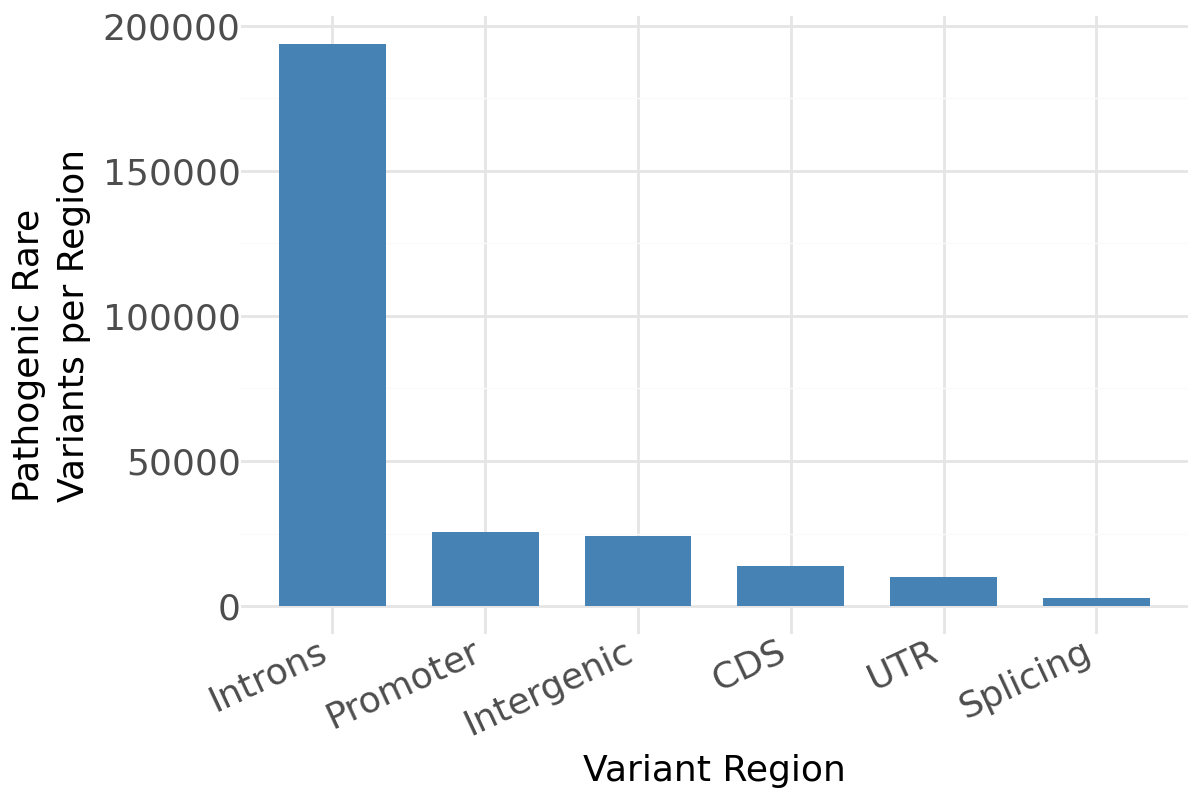

In [48]:
PLOT_TYPE = "num" 

if PLOT_TYPE == "fraction":
    y_col = "frac_patho"
    y_label = "Fraction of Pathogenic Rare\nVariants within Each Region"
else:
    y_col = "n_patho"
    y_label = "Pathogenic Rare\nVariants per Region"

# --- Plotting ---
(
    ggplot(ukbgym_patho)
    + geom_bar(
        aes(
            # Sort x-axis by the y-value in descending order using reorder(cat, -val)
            x=f"reorder(broad_consequence, -{y_col})", 
            y=y_col
        ),
        stat="identity",
        position="dodge",
        # fill="#4C72B0",
        fill="steelblue",
        width=0.7,
    )
    + labs(
        x="Variant Region",
        y=y_label,
    )
    + theme_minimal()
    + theme(
        figure_size=(6, 4),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13, lineheight=1.4),
        axis_text_x=element_text(rotation=25, hjust=1), 
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        legend_position=(0.9, 0.9), 
        legend_background=element_rect(fill="white", color='white', alpha=0.8),
        plot_background=element_rect(fill="white", color="white"),
    )
)

## Across benchmark plots

In [37]:
common_cols = ['id', 'variant_region', 'pathogenic', 'benchmark']

oth_bmrk = pl.concat([
        ukbgym_pheno.select(common_cols),
        # ukbgym_olink.select(common_cols),
        clinvar.select(common_cols), #.drop_nulls(subset=['pathogenic']),
        trait_gym_m.select(common_cols),
        trait_gym_c.select(common_cols),
        proteingym_snp.select(common_cols),
        proteingym_indel.select(common_cols),
    ],
    how="vertical"
)

oth_bmrk.write_parquet(f"{BENCH_DIR}/comparison_of_benchmarks.parquet")
!dx upload {BENCH_DIR}/comparison_of_benchmarks.parquet --path project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/

oth_bmrk

[===========================================================>] Uploaded 139,998,231 of 139,998,231 bytes (100%) /home/dnanexus/data_dir/other_benchmarks/comparison_of_benchmarks.parquet
ID                                file-J5vGby0Jg0y81k2Vv381yQJ0
Class                             file
Project                           project-Gyp4fvjJg0yFZ374KvP9bGFJ
Folder                            /processed_data/ukbgym
Name                              comparison_of_benchmarks.parquet
State                             closing
Visibility                        visible
Types                             -
Properties                        -
Tags                              -
Outgoing links                    -
Created                           Tue Jan 27 14:26:00 2026
Created by                        shubhankar
 via the job                      job-J5v79yjJg0yBj3Kv7KzX13zZ
Last modified                     Tue Jan 27 14:26:02 2026
Media type                        
archivalState                  

id,variant_region,pathogenic,benchmark
str,str,i8,str
"""chr19:7288358:C:G""","""consequence_intron_variant""",0,"""UKBBGym phenotypes"""
"""chr19:7127078:CAT:C""","""consequence_intron_variant""",0,"""UKBBGym phenotypes"""
"""chr19:7126159:G:C""","""consequence_intron_variant""",0,"""UKBBGym phenotypes"""
"""chr19:7246219:T:C""","""consequence_intron_variant""",0,"""UKBBGym phenotypes"""
"""chr19:7244780:T:G""","""consequence_intron_variant""",0,"""UKBBGym phenotypes"""
…,…,…,…
"""HRQALGGERLYPRVQAMQPAFASKITGMLL…","""frameshift_variant""",0,"""ProteinGym indel (Human)"""
"""HRQALGRLYPRVQAMQPAFASKITGMLLEL…","""frameshift_variant""",0,"""ProteinGym indel (Human)"""
"""HRQGALGERLYPRVQAMQPAFASKITGMLL…","""frameshift_variant""",0,"""ProteinGym indel (Human)"""


In [34]:
# !dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/comparison_of_benchmarks.parquet -o /home/dnanexus/data_dir/comparison_of_benchmarks.parquet

oth_bmrk = pl.read_parquet(f"{BENCH_DIR}/comparison_of_benchmarks.parquet")

# 1. Calculate the per-region stats (as you did, but we'll save it to join later)
reg_bmrk_raw = (
    oth_bmrk
    .with_columns(
        broad_consequence = pl.col("variant_region").replace_strict(consequence_map, default="Other")
    )
    .drop_nulls()
    .group_by('broad_consequence', 'benchmark')
    .agg(
        n_vars = pl.len(),
        n_patho = pl.col('pathogenic').sum().cast(pl.Int32),
    )
)

# 2. Calculate benchmark totals (Same as your code)
bmrk_plot = (
    oth_bmrk
    .group_by('benchmark')
    .agg(
        n_vars_bmrk = pl.len(),
        n_patho_bmrk = pl.col('pathogenic').sum().cast(pl.Int32),
    )
)

# --- THE FIX: Create a complete grid to ensure 0-height bars exist ---
# Get unique lists of benchmarks and consequences
unique_regions = reg_bmrk_raw.select("broad_consequence").unique()
unique_benchmarks = reg_bmrk_raw.select("benchmark").unique()

# Cross join creates every possible pair (e.g., ClinVar-Intron, ClinVar-CDS, etc.)
grid = unique_regions.join(unique_benchmarks, how="cross")

# 3. Join everything together
oth_bmrk_plot_final = (
    grid
    # Join the raw region counts onto the grid (Left Join keeps the grid structure)
    .join(reg_bmrk_raw, on=['broad_consequence', 'benchmark'], how='left')
    
    # FILL NULLS WITH 0: This turns "missing rows" into "0 variants"
    .with_columns(
        pl.col("n_vars").fill_null(0),
        pl.col("n_patho").fill_null(0)
    )
    
    # Join the benchmark totals
    .join(bmrk_plot, on='benchmark', how='left')
    
    # Calculate fractions (now safe because n_patho is 0, not null)
    .with_columns(
        frac_patho = pl.col('n_patho') / pl.col('n_vars'),
        frac_patho_bmrk_region = pl.col('n_patho') / pl.col('n_patho_bmrk')
    )
    .fill_nan(0) # Safety for division by zero
)

oth_bmrk_plot_final

broad_consequence,benchmark,n_vars,n_patho,n_vars_bmrk,n_patho_bmrk,frac_patho,frac_patho_bmrk_region
str,str,u64,i32,u64,i32,f64,f64
"""UTR""","""ClinVar""",111229,526,4280453,286303,0.004729,0.001837
"""UTR""","""ProteinGym SNP (Human)""",0,0,485830,12821,0.0,0.0
"""UTR""","""UKBBGym phenotypes""",553431,10128,27795365,270367,0.0183,0.03746
"""UTR""","""ProteinGym indel (Human)""",0,0,6944,190,0.0,0.0
"""UTR""","""TraitGym mendelian traits (mat…",2370,237,14780,1478,0.1,0.160352
…,…,…,…,…,…,…,…
"""Introns""","""ClinVar""",782822,4559,4280453,286303,0.005824,0.015924
"""Introns""","""ProteinGym SNP (Human)""",0,0,485830,12821,0.0,0.0
"""Introns""","""UKBBGym phenotypes""",23377846,193694,27795365,270367,0.008285,0.716411


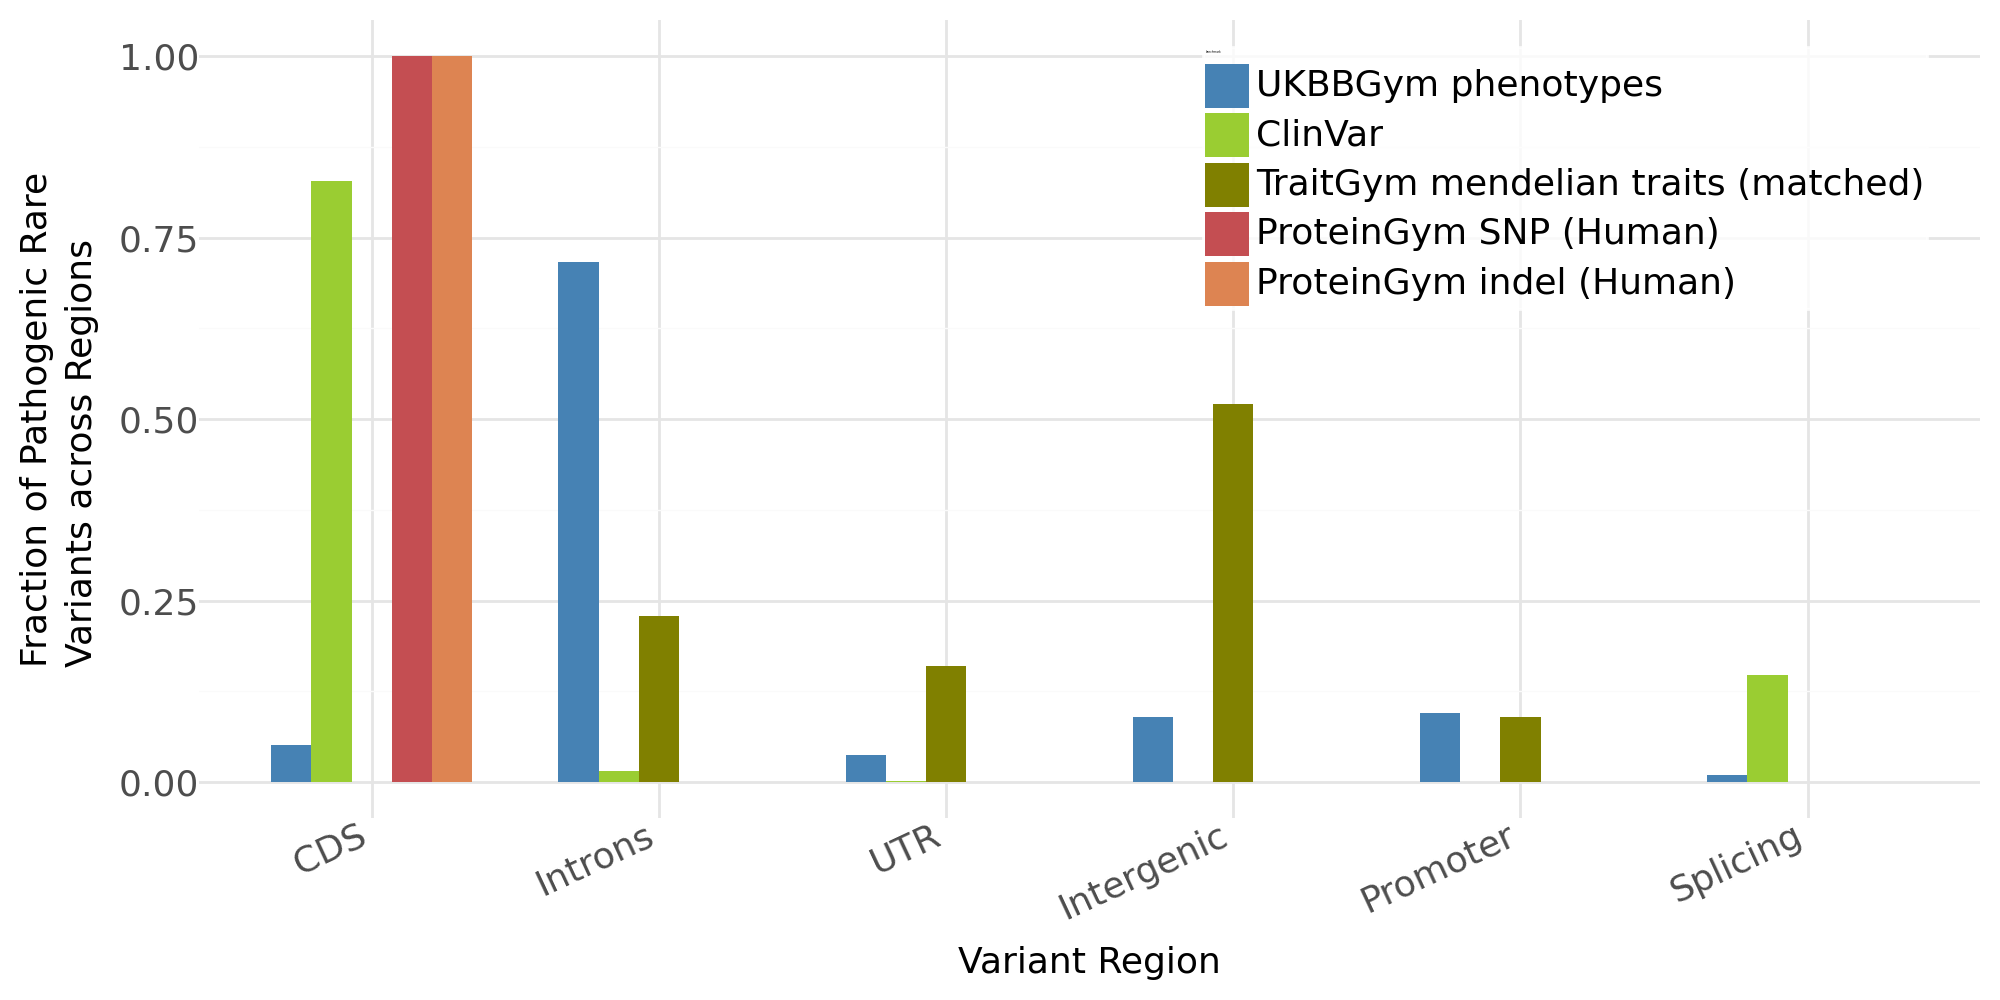

In [45]:
benchmark_colors = {
    "UKBBGym phenotypes": "steelblue",                             # Green (Standard distinct contrast)
    "ClinVar": "yellowgreen",             # Strong Blue
    "TraitGym mendelian traits (matched)": "olive", # Lighter Lavender
    "ProteinGym SNP (Human)": "#C44E52",         # Red
    "ProteinGym indel (Human)": "#DD8452",       # Orange
}

plot_df = (
    oth_bmrk_plot_final
    .filter(
        (pl.col('benchmark')!="UKBBGym Olink")
        # (pl.col('broad_consequence')!="Splicing")
    )
    .with_columns(
        # This forces the ordering based on the list provided
        pl.col("benchmark").cast(pl.Enum(benchmark_colors.keys()))
    )
)

PLOT_TYPE = "fraction" 

if PLOT_TYPE == "fraction":
    y_col = "frac_patho_bmrk_region"
    y_label = "Fraction of Pathogenic Rare\nVariants across Regions"
elif PLOT_TYPE == "frac_patho":
    y_col = "frac_patho"
    y_label = "Fraction of Pathogenic Rare\nVariants within Each Region"
elif PLOT_TYPE == "num_patho":
    y_col = "n_patho"
    y_label = "Pathogenic Rare Variants per Region"
else:
    y_col = "n_vars"
    y_label = "Rare Variants per Region"
    plot_df = plot_df.with_columns(pl.when(pl.col(y_col)==0).then(pl.col(y_col)+1).otherwise(pl.col(y_col)))

# --- Plotting ---
(
    ggplot(
        plot_df
    )
    + geom_bar(
        aes(
            # Sort x-axis by the y-value in descending order using reorder(cat, -val)
            x=f"reorder(broad_consequence, -{y_col})", 
            y=y_col,
            fill='benchmark'
        ),
        stat="identity",
        position="dodge",
        width=0.7,
    )
    + scale_fill_manual(values=benchmark_colors)
    + labs(
        x="Variant Region",
        y=y_label,
    )
    # + scale_y_sqrt()
    + theme_minimal()
    + theme(
        figure_size=(10, 5),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13, lineheight=1.4),
        axis_text_x=element_text(rotation=25, hjust=1), 
        legend_text=element_text(size=13),
        legend_title=element_text(size=0),
        legend_position=(0.95, 0.95), 
        legend_background=element_rect(fill="white", color='white', alpha=0.8),
        plot_background=element_rect(fill="white", color="white"),
    )
)

# Skipped benchmarks

## GeneticGym

In [ ]:

# !mkdir -p {BENCH_DIR}/genetics_gym
# !wget -nc https://storage.googleapis.com/genetics-gym/evaluation_tables/dd-with-combined-controls.tsv.bgz -O {BENCH_DIR}/genetics_gym/dd-with-combined-controls.tsv.bgz
# !wget -nc https://storage.googleapis.com/genetics-gym/evaluation_tables/asd-with-combined-controls.tsv.bgz -O {BENCH_DIR}/genetics_gym/asd-with-combined-controls.tsv.bgz
# !wget -nc https://storage.googleapis.com/genetics-gym/evaluation_tables/chd-with-combined-controls.tsv.bgz -O {BENCH_DIR}/genetics_gym/chd-with-combined-controls.tsv.bgz

# !wget -nc https://storage.googleapis.com/genetics-gym/evaluation_tables/schema_evaluation_table.tsv.bgz -O {BENCH_DIR}/genetics_gym/schema_evaluation_table.tsv.bgz
# !wget -nc https://storage.googleapis.com/genetics-gym/evaluation_tables/asc_evaluation_table.tsv.bgz -O {BENCH_DIR}/genetics_gym/asc_evaluation_table.tsv.bgz
# !wget -nc https://storage.googleapis.com/genetics-gym/evaluation_tables/epi25_evaluation_table.tsv.bgz -O {BENCH_DIR}/genetics_gym/epi25_evaluation_table.tsv.bgz


# !wget -nc https://storage.googleapis.com/genetics-gym/evaluation_tables/genebass_evaluation_table.tsv.bgz -O {BENCH_DIR}/genetics_gym/genebass_evaluation_table.tsv.bgz
# !wget -nc https://storage.googleapis.com/genetics-gym/evaluation_tables/gnomad-independent-set.tsv.bgz -O {BENCH_DIR}/genetics_gym/gnomad-independent-set.tsv.bgz

# geneticsgym_ddd = (
#     pl.read_csv(f"{BENCH_DIR}/genetics_gym/dd-with-combined-controls.tsv.bgz", separator="\t")
    
# )
# geneticsgym_ddd

# geneticsgym = pl.read_csv(f"{BENCH_DIR}/genetics_gym/gnomad-independent-set.tsv.bgz", separator="\t")
# geneticsgym


## UKBBGym Olink

In [ ]:

# !dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var/olink_protrider_prs_rint_all_genes_EURunrelated_appv_percentiles.parquet -o /home/dnanexus/olink_protrider_prs_rint_all_genes_EURunrelated_appv_percentiles.parquet

# olink_appv = (
#     pl.scan_parquet("/home/dnanexus/olink_protrider_prs_rint_all_genes_EURunrelated_appv_percentiles.parquet")
#     .filter(
#         (pl.col('region') + '_olink' == pl.col('phenotype')) &
#         (pl.col('n_individuals') <= mac)
#     )
#     .with_columns(
#         mean_pheno_value_rank=pl.col('mean_pheno_value')
#             .rank(method="max", descending=True)
#             .cast(pl.Float32)
#     )
#     .with_columns(
#         mean_pheno_value_ptile=(
#             pl.col('mean_pheno_value_rank') / pl.len()
#         ).cast(pl.Float32)
#     )
# )

# olink_appv

# ukbgym_olink = (
#     olink_appv
#     .join(
#         anno.lazy(), 
#         on="id", 
#         how="inner"
#     )
#     .with_columns(
#         pathogenic = pl.col('mean_pheno_value_ptile') > 0.9995,
        
#         benchmark = pl.lit("UKBBGym Olink"),
#     )
    
#     .collect(engine='streaming')
# )

# ukbgym_olink